<a href="https://colab.research.google.com/github/anika-bansal/DecodeLabs-Internship/blob/main/Project_1_Anika_Bansal_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 👤 Identification Details
###**Name:** Anika Bansal | **Email:** anikabansal1111@gmail.com | **Domain:** Data Science
---

#### **PROJECT 1**
##### Key Requirements:
##### 1) Write Python scripts to handle missing data via statistical imputation (Mean/Median/KNN).
##### 2) Identify and neutralize outliers using Z-Scores or the Interquartile Range (IQR).
##### 3)Engineer at least 3 new predictive features from existing data columns.

##### Part 1 : Import Libraries, Load Dataset & Initial EDA

In [18]:
# Import Required Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

np.random.seed(42)

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


In [19]:
# Load Dataset

df = pd.read_excel("https://github.com/anika-bansal/DecodeLabs-Internship/raw/refs/heads/main/Dataset%20for%20Data%20Analytics.xlsx")

print("\nDataset Loaded Successfully.")

print("\nShape of Dataset:")
print(df.shape)

print("\nFirst Five Records")
display(df.head())


# ============================================================
# Basic Information
# ============================================================

print("\nDataset Information")
print("-"*60)
df.info()

print("\nSummary Statistics")
display(df.describe(include='all'))


# ============================================================
# Check Data Types
# ============================================================

print("\nColumn Data Types")
print(df.dtypes)


# ============================================================
# Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print("\nNumber of Duplicate Records :", duplicates)

if duplicates > 0:
    print("Removing Duplicate Records...")
    df = df.drop_duplicates()
    print("Duplicates Removed Successfully.")
else:
    print("No Duplicate Records Found.")


# ============================================================
# Missing Values
# ============================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing = missing[missing["Missing Values"]>0]

print("\nMissing Values Summary")
display(missing.sort_values("Percentage",ascending=False))


Dataset Loaded Successfully.

Shape of Dataset:
(1200, 14)

First Five Records


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04



Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice 

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,NaN,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD201183,NaN,C46651,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK83653396,NaN,FREESHIP,Instagram,NaN
freq,1,NaN,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,2024-03-22 16:58:48,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
min,NaN,2023-01-01 00:00:00,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,2023-08-03 18:00:00,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,2024-03-23 00:00:00,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,2024-11-08 12:00:00,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000
max,NaN,2025-06-30 00:00:00,NaN,NaN,5.000000,699.930000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,3456.400000



Column Data Types
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Number of Duplicate Records : 0
No Duplicate Records Found.

Missing Values Summary


,Missing Values,Percentage
CouponCode,309,25.75


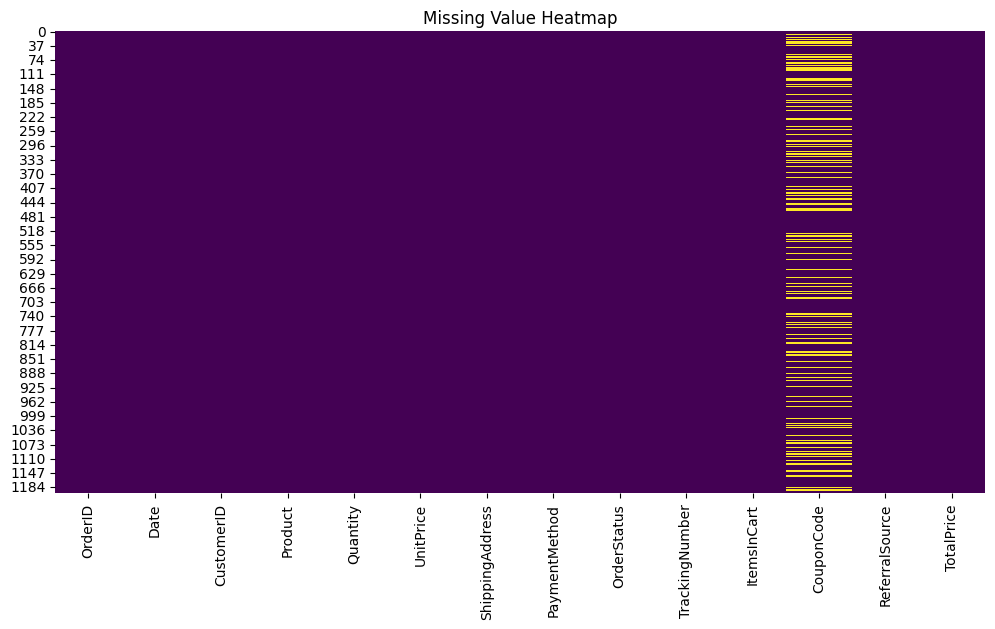


Unique Values in Each Column
------------------------------------------------------------
OrderID                   : 1200
Date                      : 671
CustomerID                : 1189
Product                   : 7
Quantity                  : 5
UnitPrice                 : 1193
ShippingAddress           : 655
PaymentMethod             : 5
OrderStatus               : 5
TrackingNumber            : 1200
ItemsInCart               : 10
CouponCode                : 3
ReferralSource            : 5
TotalPrice                : 1195

Categorical Columns
['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']

Column : OrderID


,count
OrderID,
ORD201183,1
ORD201182,1
ORD201181,1
ORD201180,1
ORD201179,1
ORD201178,1
ORD201177,1
ORD201176,1
ORD201175,1



Column : CustomerID


,count
CustomerID,
C46651,2
C56969,2
C35852,2
C38840,2
C97593,2
C21191,2
C14847,2
C91155,2
C98474,2



Column : Product


...


Column : CouponCode


,count
CouponCode,
FREESHIP,313
WINTER15,292
SAVE10,286



Column : ReferralSource


,count
ReferralSource,
Instagram,259
Email,250
Google,241
Facebook,228
Referral,222



Numerical Columns
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']


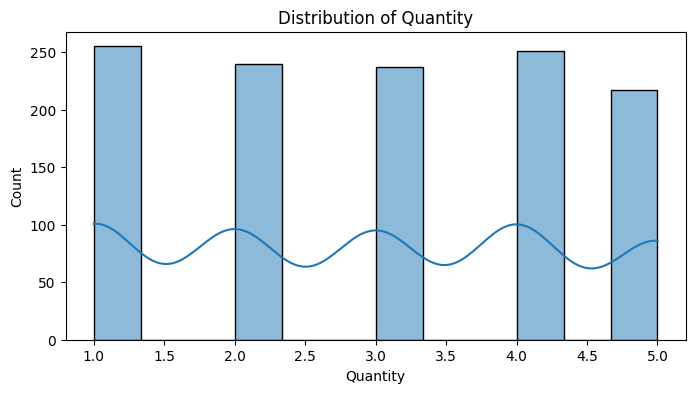

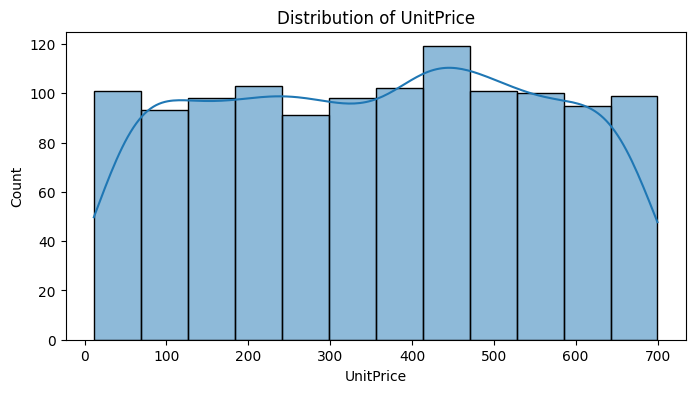

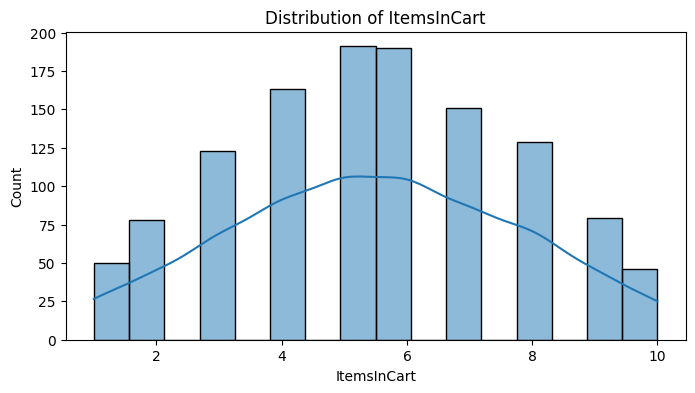

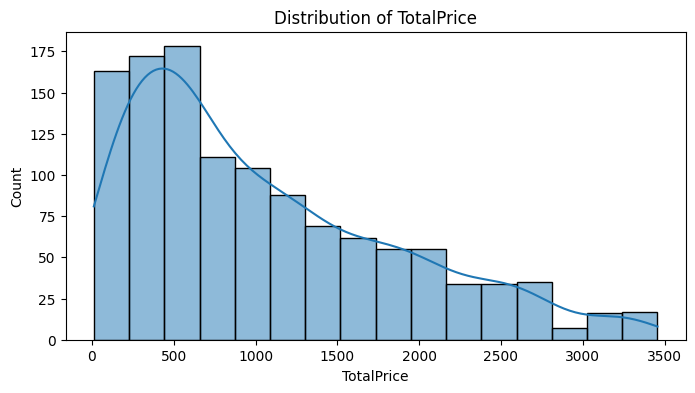

In [20]:
# ============================================================
# Missing Value Heatmap
# ============================================================

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()


# ============================================================
# Unique Values in Each Column
# ============================================================

print("\nUnique Values in Each Column")
print("-"*60)

for col in df.columns:
    print(f"{col:25s} : {df[col].nunique()}")


# ============================================================
# Categorical Column Summary
# ============================================================

categorical_columns = df.select_dtypes(include=['object']).columns

print("\nCategorical Columns")
print(categorical_columns.tolist())

for col in categorical_columns:

    print("\n"+"="*60)
    print("Column :", col)
    print("="*60)

    display(df[col].value_counts().head(10))


# ============================================================
# Numerical Column Summary
# ============================================================

numerical_columns = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns")
print(numerical_columns.tolist())


# ============================================================
# Distribution of Numerical Features
# ============================================================

for col in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

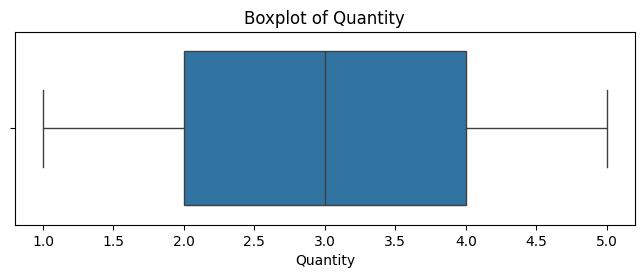

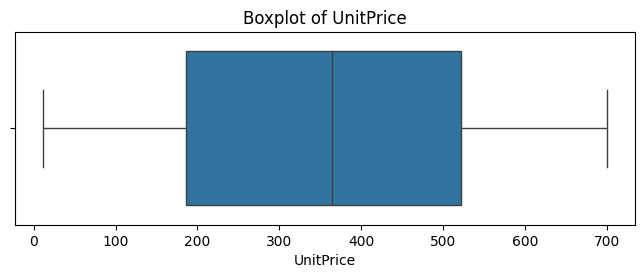

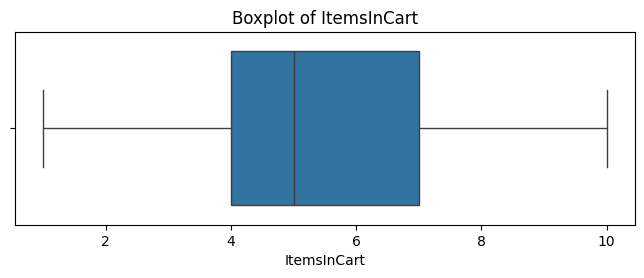

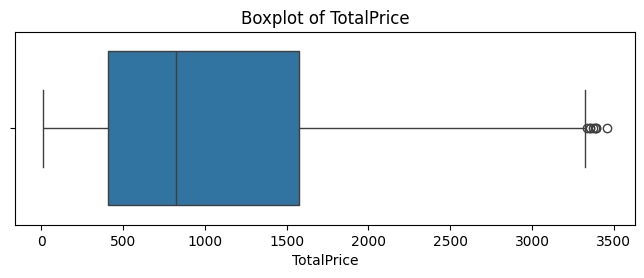

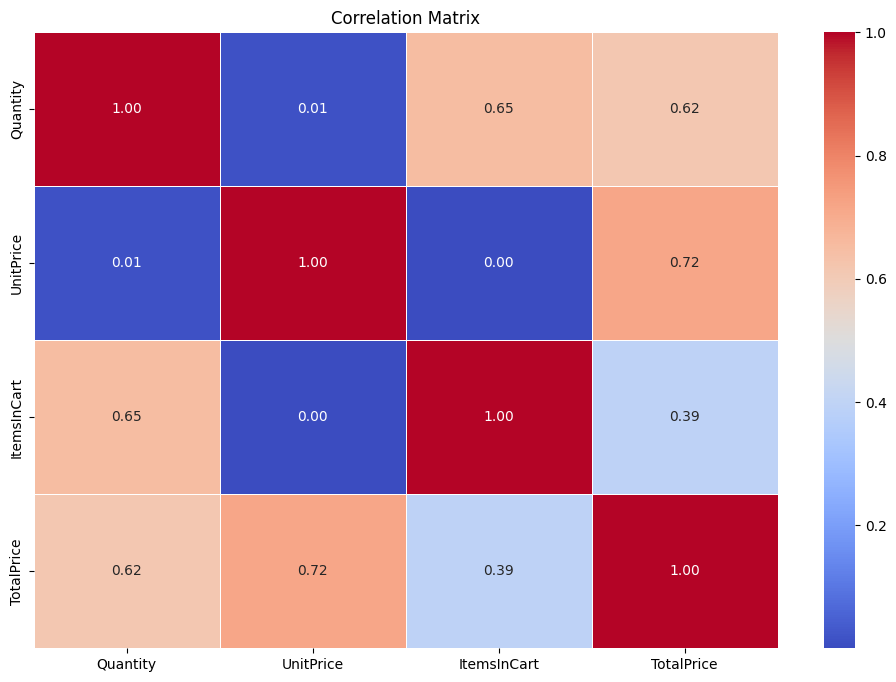


Highly Correlated Features (>|0.80|)


""



Dataset Shape : (1200, 14)

Total Features : 14
Numerical Features : 4
Categorical Features : 9
Total Missing Values : 309

EDA Completed Successfully


In [21]:
# ============================================================
# Boxplots for Numerical Variables
# ============================================================

for col in numerical_columns:

    plt.figure(figsize=(8,2.5))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()


# ============================================================
# Correlation Matrix
# ============================================================

corr = df[numerical_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()


# ============================================================
# Highly Correlated Features
# ============================================================

threshold = 0.80

high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):

        if abs(corr.iloc[i,j]) > threshold:

            high_corr.append({
                "Feature 1":corr.columns[i],
                "Feature 2":corr.columns[j],
                "Correlation":corr.iloc[i,j]
            })

high_corr = pd.DataFrame(high_corr)

print("\nHighly Correlated Features (>|0.80|)")

display(high_corr)


# ============================================================
# Dataset Overview
# ============================================================

print("\nDataset Shape :", df.shape)

print("\nTotal Features :", len(df.columns))

print("Numerical Features :", len(numerical_columns))

print("Categorical Features :", len(categorical_columns))

print("Total Missing Values :", df.isnull().sum().sum())

print("\nEDA Completed Successfully")

print("="*60)

##### Part 2 : Missing Value Handling using KNN Imputer

In [22]:
print("="*60)
print("MISSING VALUE HANDLING")
print("="*60)

# Create a working copy
df_imputed = df.copy()

# ------------------------------------------------------------
# Step 1 : Display Missing Values Before Imputation
# ------------------------------------------------------------

print("\nMissing Values Before Imputation\n")

missing_before = pd.DataFrame({
    "Missing Values": df_imputed.isnull().sum(),
    "Percentage": round(df_imputed.isnull().mean()*100,2)
})

display(missing_before[missing_before["Missing Values"]>0])

# ------------------------------------------------------------
# Step 2 : Separate Numerical & Categorical Columns, and identify Datetime columns
# ------------------------------------------------------------

# Store datetime columns separately as they don't need imputation and cause errors with KNNImputer
datetime_columns = df_imputed.select_dtypes(include='datetime').columns.tolist()
df_datetime = df_imputed[datetime_columns].copy() # Keep a copy of original datetime columns

# Create a DataFrame without datetime columns for imputation
df_imputed_no_datetime = df_imputed.drop(columns=datetime_columns)

numerical_columns = df_imputed_no_datetime.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df_imputed_no_datetime.select_dtypes(include='object').columns.tolist()

print("\nNumerical Columns (for imputation)")
print(numerical_columns)

print("\nCategorical Columns (for imputation)")
print(categorical_columns)

print("\nDatetime Columns (excluded from imputation)")
print(datetime_columns)

# ------------------------------------------------------------
# Step 3 : Encode Categorical Variables
# ------------------------------------------------------------

print("\nEncoding Categorical Variables...")

label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    # Convert to string so NaN becomes "nan"
    temp = df_imputed_no_datetime[column].astype(str)

    encoder.fit(temp)

    df_imputed_no_datetime[column] = encoder.transform(temp)

    # Convert encoded "nan" back to actual NaN
    nan_class = np.where(encoder.classes_ == "nan")[0]

    if len(nan_class) > 0:
        df_imputed_no_datetime.loc[temp == "nan", column] = np.nan

    label_encoders[column] = encoder

print("Encoding Completed.")

# ------------------------------------------------------------
# Step 4 : Apply KNN Imputer
# ------------------------------------------------------------

print("\nApplying KNN Imputer...")

knn = KNNImputer(
    n_neighbors=5,
    weights="uniform"
)

df_imputed_processed = pd.DataFrame(
    knn.fit_transform(df_imputed_no_datetime),
    columns=df_imputed_no_datetime.columns,
    index=df_imputed_no_datetime.index
)

print("KNN Imputation Completed.")

# ------------------------------------------------------------
# Step 5 : Convert Encoded Columns Back
# ------------------------------------------------------------

print("\nDecoding Categorical Variables...")

for column in categorical_columns:

    encoder = label_encoders[column]

    df_imputed_processed[column] = (
        df_imputed_processed[column]
        .round()
        .astype(int)
    )

    df_imputed_processed[column] = encoder.inverse_transform(df_imputed_processed[column])

print("Decoding Completed.")

# ------------------------------------------------------------
# Step 5.5 : Reconstruct the full df_imputed DataFrame
# ------------------------------------------------------------
# Join the processed (imputed and decoded) part with the original datetime columns
df_imputed = pd.concat([df_imputed_processed, df_datetime], axis=1)

# Ensure columns are in the original order
df_imputed = df_imputed[df.columns]

MISSING VALUE HANDLING

Missing Values Before Imputation



,Missing Values,Percentage
CouponCode,309,25.75



Numerical Columns (for imputation)
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical Columns (for imputation)
['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']

Datetime Columns (excluded from imputation)
['Date']

Encoding Categorical Variables...
Encoding Completed.

Applying KNN Imputer...
KNN Imputation Completed.

Decoding Categorical Variables...
Decoding Completed.


In [23]:
# ------------------------------------------------------------
# Step 6 : Convert Numeric Columns Back
# ------------------------------------------------------------

for column in numerical_columns:

    df_imputed[column] = pd.to_numeric(df_imputed[column])

# ------------------------------------------------------------
# Step 7 : Verify Missing Values
# ------------------------------------------------------------

print("\nMissing Values After Imputation\n")

missing_after = pd.DataFrame({
    "Missing Values": df_imputed.isnull().sum(),
    "Percentage": round(df_imputed.isnull().mean()*100,2)
})

display(missing_after[missing_after["Missing Values"]>0])

if df_imputed.isnull().sum().sum() == 0:
    print("\nAll Missing Values Successfully Imputed.")
else:
    print("\nSome Missing Values Still Exist.")

# ------------------------------------------------------------
# Step 8 : Compare Before & After
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Before": df.isnull().sum(),
    "After": df_imputed.isnull().sum()
})

comparison = comparison[
    (comparison["Before"]>0) |
    (comparison["After"]>0)
]

print("\nMissing Value Comparison")

display(comparison)

# ------------------------------------------------------------
# Step 9 : Sample Comparison
# ------------------------------------------------------------

print("\nSample of Imputed Dataset")

display(df_imputed.head())

# ------------------------------------------------------------
# Step 10 : Replace Original Dataset
# ------------------------------------------------------------

df = df_imputed.copy()

print("="*60)
print("Missing Value Treatment Completed Successfully")
print("="*60)


Missing Values After Imputation



,Missing Values,Percentage



All Missing Values Successfully Imputed.

Missing Value Comparison


,Before,After
CouponCode,309,0



Sample of Imputed Dataset


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5.0,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7.0,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2.0,151.35,823 Main St,Online,Shipped,TRK91186779,3.0,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5.0,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8.0,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1.0,273.19,275 Main St,Debit Card,Returned,TRK62788070,5.0,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4.0,626.01,668 Main St,Online,Delivered,TRK29241424,8.0,SAVE10,Email,2504.04


Missing Value Treatment Completed Successfully


##### PART 3 : Outlier Detection and Treatment

OUTLIER DETECTION AND TREATMENT

Numerical Columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Outlier Summary


,Column,Outliers,Lower Limit,Upper Limit
0,Quantity,0,-1.00,7.00
1,UnitPrice,0,-317.20,1024.83
2,ItemsInCart,0,-0.50,11.50
3,TotalPrice,8,-1341.41,3330.41



Boxplots Before Treatment


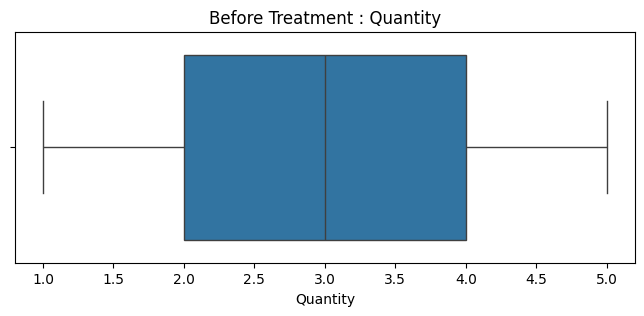

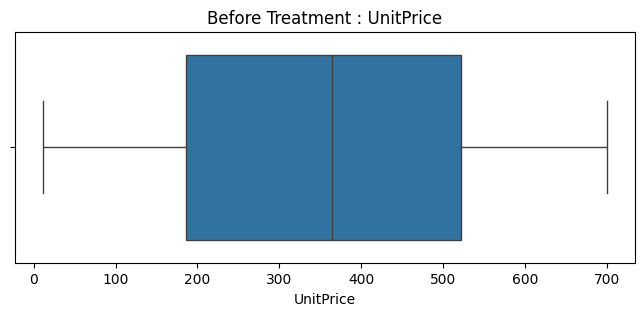

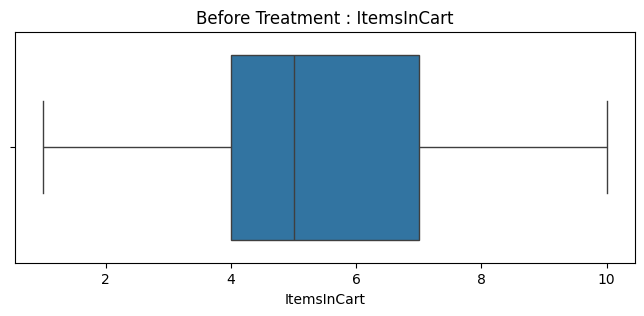

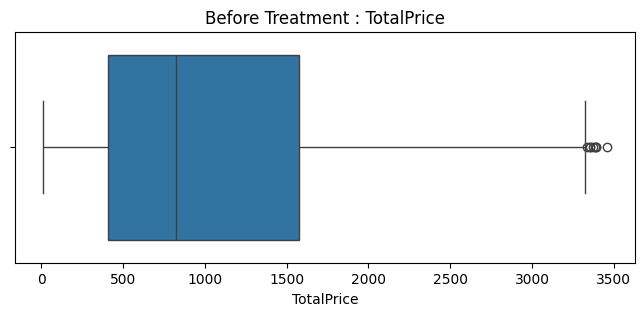

In [24]:
print("="*70)
print("OUTLIER DETECTION AND TREATMENT")
print("="*70)

# ------------------------------------------------------------
# Select Numerical Columns
# ------------------------------------------------------------

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)

# ------------------------------------------------------------
# Function to Detect Outliers using IQR
# ------------------------------------------------------------

def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    return len(outliers), lower_limit, upper_limit


# ------------------------------------------------------------
# Outlier Summary
# ------------------------------------------------------------

summary = []

for column in numerical_columns:

    count, lower, upper = detect_outliers_iqr(df, column)

    summary.append({
        "Column": column,
        "Outliers": count,
        "Lower Limit": round(lower,2),
        "Upper Limit": round(upper,2)
    })

outlier_summary = pd.DataFrame(summary)

print("\nOutlier Summary")

display(outlier_summary)

# ------------------------------------------------------------
# Boxplots BEFORE Treatment
# ------------------------------------------------------------

print("\nBoxplots Before Treatment")

for column in numerical_columns:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[column])

    plt.title(f"Before Treatment : {column}")

    plt.show()


# ------------------------------------------------------------
# Function to Cap Outliers
# ------------------------------------------------------------

def cap_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(
        data[column] < lower_limit,
        lower_limit,
        data[column]
    )

    data[column] = np.where(
        data[column] > upper_limit,
        upper_limit,
        data[column]
    )

    return data


Applying Outlier Treatment...
Outlier Treatment Completed.

Remaining Outliers


,Column,Remaining Outliers
0,Quantity,0
1,UnitPrice,0
2,ItemsInCart,0
3,TotalPrice,0



Boxplots After Treatment


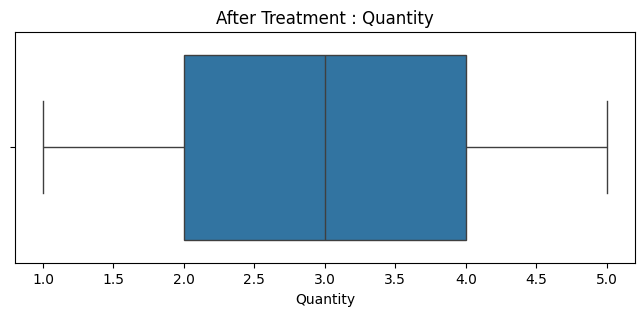

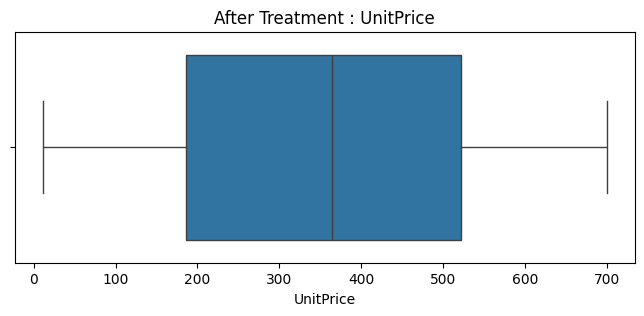

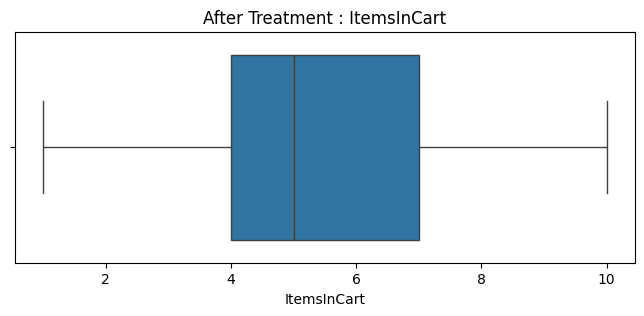

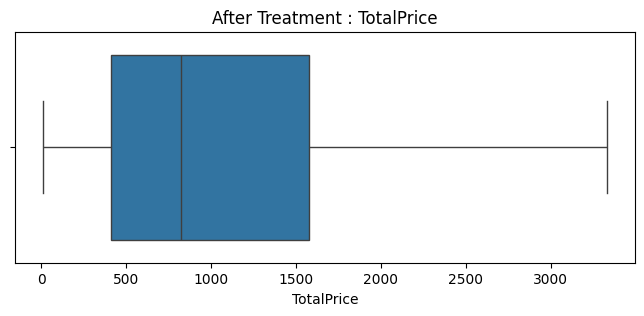


Outlier Comparison


,Column,Outliers,Lower Limit,Upper Limit,Remaining Outliers
0,Quantity,0,-1.00,7.00,0
1,UnitPrice,0,-317.20,1024.83,0
2,ItemsInCart,0,-0.50,11.50,0
3,TotalPrice,8,-1341.41,3330.41,0



Updated Summary Statistics


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.643183
std,1.407557,197.177146,2.281983,818.937858
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3330.407500


OUTLIER DETECTION & TREATMENT COMPLETED


In [25]:
# ------------------------------------------------------------
# Apply Winsorization (Capping)
# ------------------------------------------------------------

print("\nApplying Outlier Treatment...")

for column in numerical_columns:

    df = cap_outliers(df, column)

print("Outlier Treatment Completed.")

# ------------------------------------------------------------
# Verify Outliers After Treatment
# ------------------------------------------------------------

summary_after = []

for column in numerical_columns:

    count, lower, upper = detect_outliers_iqr(df, column)

    summary_after.append({
        "Column": column,
        "Remaining Outliers": count
    })

summary_after = pd.DataFrame(summary_after)

print("\nRemaining Outliers")

display(summary_after)

# ------------------------------------------------------------
# Boxplots AFTER Treatment
# ------------------------------------------------------------

print("\nBoxplots After Treatment")

for column in numerical_columns:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[column])

    plt.title(f"After Treatment : {column}")

    plt.show()


# ------------------------------------------------------------
# Before vs After Summary
# ------------------------------------------------------------

comparison = outlier_summary.merge(
    summary_after,
    on="Column"
)

print("\nOutlier Comparison")

display(comparison)

# ------------------------------------------------------------
# Statistical Summary After Treatment
# ------------------------------------------------------------

print("\nUpdated Summary Statistics")

display(df[numerical_columns].describe())

print("="*70)
print("OUTLIER DETECTION & TREATMENT COMPLETED")
print("="*70)

##### PART 4 : Feature Engineering

In [26]:
# ============================================================
# PART 4 : Feature Engineering
# ============================================================

print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

# Create a copy
df_features = df.copy()

# ------------------------------------------------------------
# Convert Date Column to Datetime
# ------------------------------------------------------------

df_features["Date"] = pd.to_datetime(df_features["Date"])

# ------------------------------------------------------------
# Feature 1 : Day of Week
# ------------------------------------------------------------

df_features["DayOfWeek"] = df_features["Date"].dt.day_name()

print("Feature Created : DayOfWeek")

# ------------------------------------------------------------
# Feature 2 : Month
# ------------------------------------------------------------

df_features["Month"] = df_features["Date"].dt.month_name()

print("Feature Created : Month")

# ------------------------------------------------------------
# Feature 3 : Order Value Per Item
# ------------------------------------------------------------

df_features["OrderValuePerItem"] = (
    df_features["TotalPrice"] /
    df_features["Quantity"]
)

print("Feature Created : OrderValuePerItem")

# ------------------------------------------------------------
# Feature 4 : Weekend Order
# ------------------------------------------------------------

df_features["IsWeekend"] = (
    df_features["Date"].dt.dayofweek >= 5
).astype(int)

print("Feature Created : IsWeekend")

# ------------------------------------------------------------
# Feature 5 : Average Price in Cart
# ------------------------------------------------------------

df_features["AverageCartValue"] = (
    df_features["TotalPrice"] /
    df_features["ItemsInCart"]
)

print("Feature Created : AverageCartValue")

# ------------------------------------------------------------
# Feature 6 : Discount Used
# ------------------------------------------------------------

df_features["CouponUsed"] = np.where(
    df_features["CouponCode"].isna(),
    0,
    1
)

print("Feature Created : CouponUsed")

# ------------------------------------------------------------
# Feature 7 : High Value Order
# ------------------------------------------------------------

threshold = df_features["TotalPrice"].median()

df_features["HighValueOrder"] = np.where(
    df_features["TotalPrice"] >= threshold,
    1,
    0
)

print("Feature Created : HighValueOrder")

# ------------------------------------------------------------
# Feature Summary
# ------------------------------------------------------------

new_features = [
    "DayOfWeek",
    "Month",
    "OrderValuePerItem",
    "IsWeekend",
    "AverageCartValue",
    "CouponUsed",
    "HighValueOrder"
]

print("\nNew Features Added")

for feature in new_features:
    print(feature)

# ------------------------------------------------------------
# Preview Dataset
# ------------------------------------------------------------

print("\nPreview of Engineered Dataset")

display(df_features.head())

# ------------------------------------------------------------
# Update Main Dataset
# ------------------------------------------------------------

df = df_features.copy()

print("\nFeature Engineering Completed Successfully.")

print("="*70)

FEATURE ENGINEERING
Feature Created : DayOfWeek
Feature Created : Month
Feature Created : OrderValuePerItem
Feature Created : IsWeekend
Feature Created : AverageCartValue
Feature Created : CouponUsed
Feature Created : HighValueOrder

New Features Added
DayOfWeek
Month
OrderValuePerItem
IsWeekend
AverageCartValue
CouponUsed
HighValueOrder

Preview of Engineered Dataset


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,DayOfWeek,Month,OrderValuePerItem,IsWeekend,AverageCartValue,CouponUsed,HighValueOrder
0,ORD200000,2023-01-04,C72649,Monitor,5.0,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7.0,SAVE10,Instagram,2853.10,Wednesday,January,570.62,0,407.585714,1,1
1,ORD200001,2024-08-23,C75739,Phone,2.0,151.35,823 Main St,Online,Shipped,TRK91186779,3.0,SAVE10,Referral,302.70,Friday,August,151.35,0,100.900000,1,0
2,ORD200002,2024-02-27,C81728,Tablet,5.0,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8.0,FREESHIP,Email,2753.40,Tuesday,February,550.68,0,344.175000,1,1
3,ORD200003,2023-10-15,C33540,Chair,1.0,273.19,275 Main St,Debit Card,Returned,TRK62788070,5.0,SAVE10,Facebook,273.19,Sunday,October,273.19,1,54.638000,1,0
4,ORD200004,2025-05-08,C81840,Printer,4.0,626.01,668 Main St,Online,Delivered,TRK29241424,8.0,SAVE10,Email,2504.04,Thursday,May,626.01,0,313.005000,1,1



Feature Engineering Completed Successfully.


##### PART 5 : Data Validation using Pandera

In [27]:
!pip install pandera

In [28]:
print("="*70)
print("DATA VALIDATION USING PANDERA")
print("="*70)

import pandera as pa
from pandera import Column, Check

# ------------------------------------------------------------
# Create Schema
# ------------------------------------------------------------

schema = pa.DataFrameSchema({

    "OrderID": Column(str),

    "Date": Column(pa.DateTime),

    "CustomerID": Column(str),

    "Product": Column(str),

    "Quantity": Column(
        int,
        Check.ge(1)
    ),

    "UnitPrice": Column(
        float,
        Check.gt(0)
    ),

    "ShippingAddress": Column(str),

    "PaymentMethod": Column(str),

    "OrderStatus": Column(str),

    "TrackingNumber": Column(str),

    "ItemsInCart": Column(
        int,
        Check.ge(1)
    ),

    "CouponCode": Column(
        object,
        nullable=True
    ),

    "ReferralSource": Column(
        object,
        nullable=True
    ),

    "TotalPrice": Column(
        float,
        Check.gt(0)
    ),

    # -------------------------
    # Engineered Features
    # -------------------------

    "DayOfWeek": Column(str),

    "Month": Column(str),

    "OrderValuePerItem": Column(
        float,
        Check.gt(0)
    ),

    "IsWeekend": Column(
        int,
        Check.isin([0,1])
    ),

    "AverageCartValue": Column(
        float,
        Check.gt(0)
    ),

    "CouponUsed": Column(
        int,
        Check.isin([0,1])
    ),

    "HighValueOrder": Column(
        int,
        Check.isin([0,1])
    )

})

# ------------------------------------------------------------
# Prepare DataFrame for Validation (Type Conversion)
# ------------------------------------------------------------
# Convert 'Quantity' and 'ItemsInCart' to int type as per schema,
# as they might have become float during imputation or other processing.
# Using .astype(int) is safe here as missing values were already handled
# and these columns contain whole numbers (e.g., 5.0 -> 5).
if 'Quantity' in df.columns:
    df['Quantity'] = df['Quantity'].astype(int)
if 'ItemsInCart' in df.columns:
    df['ItemsInCart'] = df['ItemsInCart'].astype(int)

# ------------------------------------------------------------
# Validate Dataset
# ------------------------------------------------------------

try:

    validated_df = schema.validate(df)

    print("\nDataset Validation Successful")

    # ------------------------------------------------------------
    # Additional Quality Checks (moved inside try block)
    # ------------------------------------------------------------

    print("\nAdditional Data Quality Checks")

    print("-"*50)

    print("Duplicate Records :", validated_df.duplicated().sum())

    print("Missing Values :", validated_df.isnull().sum().sum())

    print("Dataset Shape :", validated_df.shape)

    print("-"*50)

    # ------------------------------------------------------------
    # Column-wise Missing Values (moved inside try block)
    # ------------------------------------------------------------

    missing = validated_df.isnull().sum()

    missing = missing[missing>0]

    if len(missing)==0:

        print("\nNo Missing Values Found.")

    else:

        print("\nMissing Values")

        print(missing)

    # ------------------------------------------------------------
    # Preview Final Dataset (moved inside try block)
    # ------------------------------------------------------------

    print("\nValidated Dataset Preview")

    display(validated_df.head())

    # ------------------------------------------------------------
    # Replace Original Dataset (moved inside try block)
    # ------------------------------------------------------------

    df = validated_df.copy()

    print("="*70)
    print("PANDERA VALIDATION COMPLETED")
    print("="*70)

except Exception as e:

    print("\nValidation Failed")

    print(e)

    print("\nPandera validation could not complete. Please check the reported error above.")

DATA VALIDATION USING PANDERA

Dataset Validation Successful

Additional Data Quality Checks
--------------------------------------------------
Duplicate Records : 0
Missing Values : 0
Dataset Shape : (1200, 21)
--------------------------------------------------

No Missing Values Found.

Validated Dataset Preview


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,DayOfWeek,Month,OrderValuePerItem,IsWeekend,AverageCartValue,CouponUsed,HighValueOrder
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,Wednesday,January,570.62,0,407.585714,1,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,Friday,August,151.35,0,100.900000,1,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,Tuesday,February,550.68,0,344.175000,1,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,Sunday,October,273.19,1,54.638000,1,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,Thursday,May,626.01,0,313.005000,1,1


PANDERA VALIDATION COMPLETED


##### PART 6 : Feature Store using Feast

In [29]:
!pip install feast
from feast import Entity
from feast import Field
from feast import FeatureView
from feast import FileSource
from feast.types import Float32, Int64
from datetime import timedelta

In [30]:
# ------------------------------------------------------------
# Save Engineered Dataset
# ------------------------------------------------------------

feature_df = df.copy()

feature_df.to_csv("engineered_features.csv", index=False)

print("Engineered Feature Dataset Saved Successfully.")

# ------------------------------------------------------------
# Create Data Source
# ------------------------------------------------------------

customer_source = FileSource(
    path="engineered_features.csv",
    timestamp_field="Date"
)

print("Feature Source Created Successfully.")

# ------------------------------------------------------------
# Define Entity
# ------------------------------------------------------------
customer = Entity(
    name="CustomerID",
    join_keys=["CustomerID"]
)

print("Entity Created Successfully.")


Engineered Feature Dataset Saved Successfully.
Feature Source Created Successfully.
Entity Created Successfully.


In [31]:
# ------------------------------------------------------------
# Define Feature View
# ------------------------------------------------------------

customer_features = FeatureView(

    name="customer_features",

    entities=[customer],

    ttl=timedelta(days=30),

    schema=[

        Field(
            name="Quantity",
            dtype=Int64
        ),

        Field(
            name="UnitPrice",
            dtype=Float32
        ),

        Field(
            name="ItemsInCart",
            dtype=Int64
        ),

        Field(
            name="TotalPrice",
            dtype=Float32
        ),

        Field(
            name="OrderValuePerItem",
            dtype=Float32
        ),

        Field(
            name="AverageCartValue",
            dtype=Float32
        ),

        Field(
            name="CouponUsed",
            dtype=Int64
        ),

        Field(
            name="HighValueOrder",
            dtype=Int64
        ),

        Field(
            name="IsWeekend",
            dtype=Int64
        )

    ],

    source=customer_source

)

print("Feature View Created Successfully.")



Feature View Created Successfully.


In [32]:
# ------------------------------------------------------------
# Display Feature Store Information
# ------------------------------------------------------------

print("="*60)

print("Feature Store Summary")

print("="*60)

print("Entity :", customer.name)

print("Feature View :", customer_features.name)

print("TTL :", customer_features.ttl)

print("Source :", customer_source.path)

print("="*60)

# ------------------------------------------------------------
# Display Stored Features
# ------------------------------------------------------------
selected_features = [

    "CustomerID",

    "Quantity",

    "ItemsInCart",

    "TotalPrice",

    "OrderValuePerItem",

    "AverageCartValue",

    "CouponUsed",

    "HighValueOrder",

    "IsWeekend"

]

display(df[selected_features].head(10))

# ------------------------------------------------------------
# Display Stored Features
# ------------------------------------------------------------
selected_features = [

    "CustomerID",

    "Quantity",

    "ItemsInCart",

    "TotalPrice",

    "OrderValuePerItem",

    "AverageCartValue",

    "CouponUsed",

    "HighValueOrder",

    "IsWeekend"

]

display(df[selected_features].head(10))


Feature Store Summary
Entity : CustomerID
Feature View : customer_features
TTL : 30 days, 0:00:00
Source : engineered_features.csv


,CustomerID,Quantity,ItemsInCart,TotalPrice,OrderValuePerItem,AverageCartValue,CouponUsed,HighValueOrder,IsWeekend
0,C72649,5,7,2853.10,570.62,407.585714,1,1,0
1,C75739,2,3,302.70,151.35,100.900000,1,0,0
2,C81728,5,8,2753.40,550.68,344.175000,1,1,0
3,C33540,1,5,273.19,273.19,54.638000,1,0,1
4,C81840,4,8,2504.04,626.01,313.005000,1,1,0
5,C37249,2,4,491.72,245.86,122.930000,1,0,0
6,C83492,1,6,664.42,664.42,110.736667,1,0,0
7,C41460,5,9,747.75,149.55,83.083333,1,0,0
8,C26817,2,2,268.56,134.28,134.280000,1,0,0
9,C31946,4,6,2037.52,509.38,339.586667,1,1,0


,CustomerID,Quantity,ItemsInCart,TotalPrice,OrderValuePerItem,AverageCartValue,CouponUsed,HighValueOrder,IsWeekend
0,C72649,5,7,2853.10,570.62,407.585714,1,1,0
1,C75739,2,3,302.70,151.35,100.900000,1,0,0
2,C81728,5,8,2753.40,550.68,344.175000,1,1,0
3,C33540,1,5,273.19,273.19,54.638000,1,0,1
4,C81840,4,8,2504.04,626.01,313.005000,1,1,0
5,C37249,2,4,491.72,245.86,122.930000,1,0,0
6,C83492,1,6,664.42,664.42,110.736667,1,0,0
7,C41460,5,9,747.75,149.55,83.083333,1,0,0
8,C26817,2,2,268.56,134.28,134.280000,1,0,0
9,C31946,4,6,2037.52,509.38,339.586667,1,1,0


In [33]:
print("="*70)
print("FEATURE STORE IMPLEMENTATION COMPLETED")
print("="*70)

FEATURE STORE IMPLEMENTATION COMPLETED


##### PART 7 : Final Dataset Validation & Project Summary

In [34]:
# ============================================================
# PART 7 : Final Dataset Validation & Project Summary
# ============================================================

print("="*80)
print("FINAL DATASET VALIDATION")
print("="*80)

# ------------------------------------------------------------
# Dataset Shape
# ------------------------------------------------------------

print("\nDataset Shape")
print(df.shape)

# ------------------------------------------------------------
# Data Types
# ------------------------------------------------------------

print("\nData Types")
display(df.dtypes)

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------

print("\nMissing Values")

missing = df.isnull().sum()

display(missing)

if missing.sum() == 0:
    print("\nAll missing values have been handled successfully.")
else:
    print("\nSome missing values are still present.")

# ------------------------------------------------------------
# Duplicate Records
# ------------------------------------------------------------

duplicates = df.duplicated().sum()

print("\nDuplicate Records :", duplicates)

if duplicates == 0:
    print("No duplicate records found.")
else:
    print("Dataset still contains duplicate records.")

# ------------------------------------------------------------
# Numerical Summary
# ------------------------------------------------------------

print("\nSummary Statistics")

display(df.describe())

# ------------------------------------------------------------
# Final Feature List
# ------------------------------------------------------------

print("\nFinal Features in Dataset")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

# ------------------------------------------------------------
# Newly Engineered Features
# ------------------------------------------------------------

engineered_features = [

    "DayOfWeek",

    "Month",

    "OrderValuePerItem",

    "IsWeekend",

    "AverageCartValue",

    "CouponUsed",

    "HighValueOrder"

]

print("\nEngineered Features")

for feature in engineered_features:
    print("✔", feature)

# ------------------------------------------------------------
# Preview Final Dataset
# ------------------------------------------------------------

print("\nFinal Dataset Preview")

display(df.head())

# ------------------------------------------------------------
# Save Final Dataset
# ------------------------------------------------------------

df.to_csv("Processed_ECommerce_Dataset.csv", index=False)

print("\nProcessed dataset saved successfully.")

# ------------------------------------------------------------
# Project Summary
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Task":[

        "Initial Data Exploration",

        "Missing Value Handling",

        "Outlier Treatment",

        "Feature Engineering",

        "Pandera Validation",

        "Feature Store (Feast)",

        "Final Validation"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

print("\nProject Completion Summary")

display(summary)

# ------------------------------------------------------------
# Final Success Message
# ------------------------------------------------------------

print("="*80)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*80)

print("""
Project Objectives Achieved

✔ Performed Exploratory Data Analysis (EDA)

✔ Handled Missing Values using KNN Imputer

✔ Detected and Treated Outliers using IQR Method

✔ Created New Predictive Features

✔ Validated Dataset using Pandera

✔ Implemented a Basic Feature Store using Feast

✔ Generated a Clean, Machine Learning Ready Dataset

The dataset is now ready for Machine Learning model development.
""")

FINAL DATASET VALIDATION

Dataset Shape
(1200, 21)

Data Types


,0
OrderID,object
Date,datetime64[ns]
CustomerID,object
Product,object
Quantity,int64
UnitPrice,float64
ShippingAddress,object
PaymentMethod,object
OrderStatus,object
TrackingNumber,object



Missing Values


,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0



All missing values have been handled successfully.

Duplicate Records : 0
No duplicate records found.

Summary Statistics


...


Final Features in Dataset
1. OrderID
2. Date
3. CustomerID
4. Product
5. Quantity
6. UnitPrice
7. ShippingAddress
8. PaymentMethod
9. OrderStatus
10. TrackingNumber
11. ItemsInCart
12. CouponCode
13. ReferralSource
14. TotalPrice
15. DayOfWeek
16. Month
17. OrderValuePerItem
18. IsWeekend
19. AverageCartValue
20. CouponUsed
21. HighValueOrder

Engineered Features
✔ DayOfWeek
✔ Month
✔ OrderValuePerItem
✔ IsWeekend
✔ AverageCartValue
✔ CouponUsed
✔ HighValueOrder

Final Dataset Preview


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,DayOfWeek,Month,OrderValuePerItem,IsWeekend,AverageCartValue,CouponUsed,HighValueOrder
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,Wednesday,January,570.62,0,407.585714,1,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,Friday,August,151.35,0,100.900000,1,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,Tuesday,February,550.68,0,344.175000,1,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,Sunday,October,273.19,1,54.638000,1,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,Thursday,May,626.01,0,313.005000,1,1



Processed dataset saved successfully.

Project Completion Summary


,Task,Status
0,Initial Data Exploration,Completed
1,Missing Value Handling,Completed
2,Outlier Treatment,Completed
3,Feature Engineering,Completed
4,Pandera Validation,Completed
5,Feature Store (Feast),Completed
6,Final Validation,Completed


PROJECT COMPLETED SUCCESSFULLY

Project Objectives Achieved

✔ Performed Exploratory Data Analysis (EDA)

✔ Handled Missing Values using KNN Imputer

✔ Detected and Treated Outliers using IQR Method

✔ Created New Predictive Features

✔ Validated Dataset using Pandera

✔ Implemented a Basic Feature Store using Feast

✔ Generated a Clean, Machine Learning Ready Dataset

The dataset is now ready for Machine Learning model development.

